## Random variables

[Discrete Random Variables](https://saylordotorg.github.io/text_introductory-statistics/s08-discrete-random-variables.html)

[Continious Random Variables](https://saylordotorg.github.io/text_introductory-statistics/s09-continuous-random-variables.html)

**Key Concepts**
A random variable is a numerical quantity that is generated by a random experiment.

A random variable is called discrete if it has either a finite or a countable number of possible values. A random variable is called continuous if its possible values contain a whole interval of numbers.

**Probabilities**
The probability distribution of a discrete random variable X is a list of each possible value of X together with the probability that X takes that value in one trial of the experiment.

In [1]:
# A pair of fair dice is rolled. Let X denote the sum of the number of dots on the top faces.

# Construct the probability distribution of X.
# Find P(X ≥ 9).
# Find the probability that X takes an even value.

# first lets generate all possible outcomes
possible_outcomes = []
for i in range(1, 7):
    for j in range(1, 7):
        possible_outcomes.append({
            "outcome": (i, j),
            "sum": i + j
        })

# now we can generate the probability distribution
unique_outcomes = set([outcome["sum"] for outcome in possible_outcomes])
probability_distribution = {}
for outcome in unique_outcomes:
    probability_distribution[outcome] = len([o["sum"] for o in possible_outcomes if o["sum"] == outcome]) / len(possible_outcomes)

# Find P(X ≥ 9).
p_x_greater_than_9 = sum([probability_distribution[o] for o in unique_outcomes if o >= 9])


#
p_x_even = sum([probability_distribution[o] for o in unique_outcomes if o % 2 == 0])

print("possible_outcomes", possible_outcomes)
print("unique_outcomes", unique_outcomes)
print("probability_distribution", probability_distribution)
print("P(X ≥ 9)", p_x_greater_than_9)
print("P(X even)", p_x_even)


possible_outcomes [{'outcome': (1, 1), 'sum': 2}, {'outcome': (1, 2), 'sum': 3}, {'outcome': (1, 3), 'sum': 4}, {'outcome': (1, 4), 'sum': 5}, {'outcome': (1, 5), 'sum': 6}, {'outcome': (1, 6), 'sum': 7}, {'outcome': (2, 1), 'sum': 3}, {'outcome': (2, 2), 'sum': 4}, {'outcome': (2, 3), 'sum': 5}, {'outcome': (2, 4), 'sum': 6}, {'outcome': (2, 5), 'sum': 7}, {'outcome': (2, 6), 'sum': 8}, {'outcome': (3, 1), 'sum': 4}, {'outcome': (3, 2), 'sum': 5}, {'outcome': (3, 3), 'sum': 6}, {'outcome': (3, 4), 'sum': 7}, {'outcome': (3, 5), 'sum': 8}, {'outcome': (3, 6), 'sum': 9}, {'outcome': (4, 1), 'sum': 5}, {'outcome': (4, 2), 'sum': 6}, {'outcome': (4, 3), 'sum': 7}, {'outcome': (4, 4), 'sum': 8}, {'outcome': (4, 5), 'sum': 9}, {'outcome': (4, 6), 'sum': 10}, {'outcome': (5, 1), 'sum': 6}, {'outcome': (5, 2), 'sum': 7}, {'outcome': (5, 3), 'sum': 8}, {'outcome': (5, 4), 'sum': 9}, {'outcome': (5, 5), 'sum': 10}, {'outcome': (5, 6), 'sum': 11}, {'outcome': (6, 1), 'sum': 7}, {'outcome': (6, 2

**The Mean and Standard Deviation of a Discrete Random Variable**

The mean (also called the expected value) of a discrete random variable X is the number **μ=E(X)=ΣxP(x)**

The mean of a random variable may be interpreted as the average of the values assumed by the random variable in repeated trials of the experiment.

![image](media/task1.png)


In [2]:
μ = (-2) * 0.21 + (1) * 0.34 + 2 * 0.24 + 3.5 * 0.21 
print("Expected value", μ)

Expected value 1.135


In [3]:
# A service organization in a large town organizes a raffle each month. One thousand raffle tickets are sold for $1 each. Each has an equal chance of winning. First prize is $300, second prize is $200, and third prize is $100. Let X denote the net gain from the purchase of one ticket.

# Construct the probability distribution of X.
# Find the probability of winning any money in the purchase of one ticket.
# Find the expected value of X, and interpret its meaning.

# probability distribution of X
possible_outcomes = {
    '100' : 1/1000,
    '200' : 1/1000,
    '300' : 1/1000,
    '-1' : 997/1000
}

# probability of winning any money in the purchase of one ticket
p_winning = sum([possible_outcomes[o] for o in possible_outcomes if o!='-1'])

# Expected value of X
expected_value = sum([possible_outcomes[o] * int(o) for o in possible_outcomes])
print('probability distribution of X', possible_outcomes)
print('probability of winning any money in the purchase of one ticket', p_winning)
print('expected value of X', expected_value)




probability distribution of X {'100': 0.001, '200': 0.001, '300': 0.001, '-1': 0.997}
probability of winning any money in the purchase of one ticket 0.003
expected value of X -0.397


Next : variance, standard deviation, continious random variable, distributions

I skip randopm variable variance and standard deviation as those are highly theoretical concepts. 

## The Binomial Distribution

The binomial distribution is a probability distribution that describes the number of successes in a fixed number of independent trials, where each trial has only two possible outcomes and the probability of success remains constant.

![image.png](https://www.onlinemathlearning.com/image-files/binomial-distribution-formula.png)

**Example**
If the historical email response rate is 15%, that means each email has a probability ( p = 0.15 ) of getting a response. If we send 1000 emails, we can model the number of responses using a binomial distribution with ( n = 1000 ) and ( p = 0.15 ). This does not guarantee we will get exactly 150 responses, but 150 is the expected (average) number. The binomial distribution tells us the probability of getting exactly ( k ) responses, such as 140, 150, or 170. It helps us understand the likely variation around the expected value due to randomness.


In [2]:
from math import factorial, comb
from scipy.stats import binom

# Example using the Ideals expansion case study

n_account = 10000 # number of accounts
n_expansions = 1000 # number of expansions
p_expansion = n_expansions / n_account # probability of expansion

# Question: what is the probability that next 1000 accounts will have 100 expansions?
n = 1000
k = 100
p_x = (factorial(n) / (factorial(n-k) * factorial(k))) * p_expansion**k * (1-p_expansion)**(n-k)
print("Probability that next 1000 accounts will have 100 expansions", round(p_x * 100, 2), '%')

# Question: what is the probability that next 1000 accounts will have 150 expansions?
# Using comb because factorial is not a good idea for large numbers
n = 2000
k = 200
p_x = (comb(n, k) * p_expansion**k * (1-p_expansion)**(n-k))
print("Probability that next 1000 accounts will have 150 expansions", round(p_x * 100, 5), '%')

# Or using scipy
p_x = binom.pmf(k, n, p_expansion)
print("Probability that next 1000 accounts will have 150 expansions", round(p_x * 100, 5), '%')


Probability that next 1000 accounts will have 100 expansions 4.2 %
Probability that next 1000 accounts will have 150 expansions 2.97229 %
Probability that next 1000 accounts will have 150 expansions 2.97229 %


**Task**

A student takes a ten-question true/false exam.

Find the probability that the student gets exactly six of the questions right simply by guessing the answer on every question.
Find the probability that the student will obtain a passing grade of 60% or greater simply by guessing.

In [38]:
# a
n = 10
k = 6
p_correct = 0.5
p_incorrect = 1 - p_correct


p_x = (factorial(n) / (factorial(n-k) * factorial(k))) * p_correct**k * p_incorrect**(n-k)
print("Chance of getting exactly six of the questions right simply by guessing", p_x)


# b (cumulaive probability, read below)
# we can either calculate 1 - P(X<=5) or P(X>=6)
# P(X<=5) = P(0)+P(1)+P(2)+P(3)+P(4)+P(5)
# P(X>=6) = 1 - P(X<=5)

p_x_less_than_5 = 0
for i in range(5):
    i = i + 1 # to start from 1
    p_x_less_than_5 += (factorial(n) / (factorial(n-i) * factorial(i))) * p_correct**i * p_incorrect**(n-i)

p_x_more_than_5 = 1 - p_x_less_than_5
print("Chance of getting 60% or greater simply by guessing", p_x_more_than_5)



Chance of getting exactly six of the questions right simply by guessing 0.205078125
Chance of getting 60% or greater simply by guessing 0.3779296875


**Cumulative Probability**

P(X≤x)=P(0)+P(1)+· · ·+P(x)

P(X≥x)=1−P(X≤x−1)andP(x)=P(X≤x)−P(X≤x−1)

The reason for providing a cumulative table is that in practical problems that involve a binomial random variable typically the probability that is sought is of the form P(X≤x) or P(X≥x)

![image](https://saylordotorg.github.io/text_introductory-statistics/section_08/a939536e3189562fdfb0f9323e6c3e68.jpg)

In [ ]:
from scipy.stats import binom

# Continuation of Ideals example but with cumulative probability

n_account = 10000 # number of accounts
n_expansions = 1000 # number of expansions
p_expansion = n_expansions / n_account # probability of expansion

# Question: what is the probability that next 1000 accounts will have >=100 expansions?
p_x_less_than_100 = binom.cdf(99, 1000, p_expansion)
p_x_more_than_100 = 1 - p_x_less_than_100
print("Chance of getting >=100 expansions", round(p_x_more_than_100 * 100, 5), '%')

# Question: what is the probability that next 1000 accounts will have between 100 and 150 expansions?
p_x_less_than_100 = binom.cdf(99, 1000, p_expansion)
p_x_less_than_150 = binom.cdf(149, 1000, p_expansion)
p_x_between_100_and_150 = p_x_less_than_150 - p_x_less_than_100
print("Chance of getting between 100 and 150 expansions", round(p_x_between_100_and_150 * 100, 5), '%')

Chance of getting >=100 expansions 51.54177 %
Chance of getting between 100 and 150 expansions 51.54173 %


1. **Reliability of binomial distribution:**

   * Mathematically exact if assumptions hold: fixed number of trials, two outcomes, constant probability, and independence.
   * In practice, small deviations (like changing probabilities or dependent trials) reduce precision. So results are **probabilistic estimates**, not guarantees.

2. **Business application:**

   * Binomial distribution is widely used in business for marketing, sales, repeat purchases, and quality control.
   * It helps **quantify risk and expectations**, e.g., probability of a certain number of customer responses or repeat purchases.

3. **Required sample size:**

   * More historical data makes your probability estimate more reliable.
   * Common rule of thumb: ( n \cdot p \ge 10 ) and ( n \cdot (1-p) \ge 10 ) for good approximation.
   * Small sample sizes produce noisy estimates; large n gives more confidence.

4. **Independence of trials:**

   * True independence rarely exists in business because client decisions depend on satisfaction, quality, or other factors.
   * Binomial can still be used approximately if:

     * Individual decisions are not strongly correlated
     * p is treated as an average across all clients
     * You accept results are probabilistic, not exact

5. **Applying to your use case (5% repeat clients):**

   * Yes, binomial can model the probability of 5 out of 100 clients returning.
   * ( n = 100 ), ( p = 0.05 ), ( k = 5 ) → compute ( P(X=5) ) or cumulative probabilities.
   * For skewed probabilities (like low p and large n), Poisson approximation or Poisson binomial (for varying probabilities) can improve accuracy.

---

✅ **Key takeaway:**
Binomial distribution is a **practical tool for business**, providing probabilities and expected ranges, even if assumptions (especially independence) are only approximate. Historical data informs the probability, and larger samples increase reliability.

Next : continious random variable

## Continious random variable

The probability distribution of a continuous random variable X is an assignment of probabilities to intervals of decimal numbers using a function f(x)
, called a density function, in the following way: the probability that X assumes a value in the interval [a,b]
 is equal to the area of the region that is bounded above by the graph of the equation y=f(x)
, bounded below by the x-axis, and bounded on the left and right by the vertical lines through a and b, as illustrated in Figure 5.1 "Probability Given as Area of a Region under a Curve".


![image](https://saylordotorg.github.io/text_introductory-statistics/section_09/a4a078a33c22b212350844a6cd8789b6.jpg)

## Normal distribution

**Definition**

The probability distribution corresponding to the density function for the bell curve with parameters μ and σ is called the normal distribution with mean μ and standard deviation σ.

**Definition**

A continuous random variable whose probabilities are described by the normal distribution with mean μ and standard deviation σ is called a normally distributed random variable, or a normal random variable for short, with mean μ and standard deviation σ.


![normal distrubution](https://www.onlinemathlearning.com/image-files/normal-distribution-formula.png)

[0.012788852587822285, 0.03105686071378889, 0.06269130102773252, 0.10519152880154807, 0.14671617861603797, 0.14671617861603797, 0.17009791972148675, 0.17009791972148675, 0.17009791972148675, 0.16392445687296509, 0.16392445687296509, 0.16392445687296509, 0.16392445687296509, 0.13131437174365426, 0.13131437174365426, 0.13131437174365426, 0.13131437174365426, 0.08743886721723591, 0.08743886721723591, 0.04839723390931691]


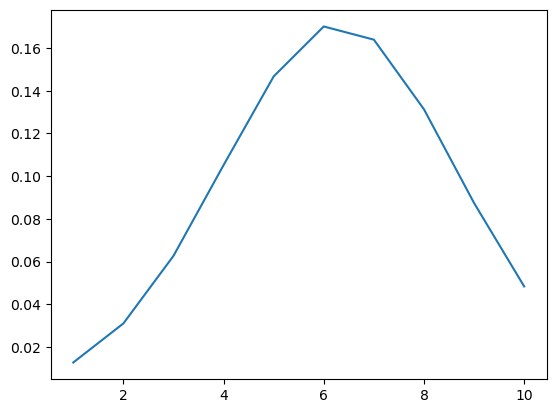

In [ ]:
# Normal probability density function
import numpy as np
from matplotlib import pyplot as plt

x = [1,2,3,4,5,5,6,6,6,7,7,7,7,8,8,8,8,9,9,10]

mean = np.mean(x)
std = np.std(x)

normal_pdf = []

for i in x:
    step_1 = 1 / (std * np.sqrt(2 * np.pi))
    step_2 = np.exp(-(i - mean)**2 / (2 * std**2))
    step_3 = step_1 * step_2
    normal_pdf.append(step_3)

print(normal_pdf)


plt.plot(x, normal_pdf)
plt.show()

Empirical Rule states that,

68% of the data approximately fall within one standard deviation of the mean, i.e. it falls between {Mean - One Standard Deviation, and Mean + One Standard Deviation}
95% of the data approximately fall within two standard deviations of the mean, i.e. it falls between {Mean - Two Standard Deviation, and Mean + Two Standard Deviation}
99.7% of the data approximately fall within a third standard deviation of the mean, i.e. it falls between {Mean - Third Standard Deviation, and Mean + Third Standard Deviation}


![image](https://media.geeksforgeeks.org/wp-content/uploads/20230901155813/Probability-Distribution-Curve.png)

[0.029746112355660773, 0.07223641541432305, 0.14581624671076368, 0.24466925497085534, 0.3412531267786714, 0.3412531267786714, 0.3956376693494357, 0.3956376693494357, 0.3956376693494357, 0.38127856103580293, 0.38127856103580293, 0.38127856103580293, 0.38127856103580293, 0.30542943778390075, 0.30542943778390075, 0.30542943778390075, 0.30542943778390075, 0.2033776173925311, 0.2033776173925311, 0.11256909466143743]


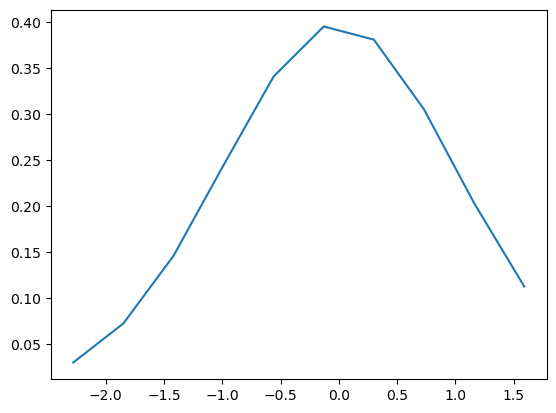

In [4]:
import numpy as np
from matplotlib import pyplot as plt

x = [1,2,3,4,5,5,6,6,6,7,7,7,7,8,8,8,8,9,9,10]

mean = np.mean(x)
std = np.std(x)

# convert x values to z-scores (standardized values)
z_scores = [(i - mean) / std for i in x]

standard_normal_pdf = []

for z in z_scores:
    step_1 = 1 / np.sqrt(2 * np.pi)
    step_2 = np.exp(-(z**2) / 2)
    step_3 = step_1 * step_2
    standard_normal_pdf.append(step_3)

print(standard_normal_pdf)

plt.plot(z_scores, standard_normal_pdf)
plt.show()

**Question:** is the shape of The Standard Normal Distribution the same as of normal distribution for same values?

**Answer:** Yes — the shape is the same. The standard normal distribution and the normal distribution for your original data have the same bell shape, but one is just shifted and stretched compared to the other.

**Task**

If a dataset follows a normal distribution with a mean of 100 and a standard deviation of 15, what is the Z-score for a value of 130? Interpret the Z-score.

In [24]:
mean = 100
std = 15
x = 130

z_score = (x - mean) / std
print("The value of 130 is", z_score, "standard deviations above the mean")

The value of 130 is 2.0 standard deviations above the mean


**Task**

Given a normal distribution with a mean of 70 and a standard deviation of 10, find the probability that a randomly selected value falls between 60 and 80.

**Solution** : P(60 < x < 80) = P(x<80) - P(x<60)

In [ ]:
from scipy.stats import norm

mean = 70
std = 10

# using the Cumulative Distribution Function
prob = norm.cdf(80, mean, std) - norm.cdf(60, mean, std)

print(prob)

0.6826894921370859


In [22]:
# Another way to solve the task is to use the standard normal table
z_80 = (80 - mean) / std
z_60 = (60 - mean) / std
print('z_80', z_80)
print('z_60', z_60)

# the problem becomes P(−1<Z<1) to find from the standard normal table
p_z_80 = 0.84
p_z_60 = 0.16

prob = p_z_80 - p_z_60
print("probability that a randomly selected value falls between 60 and 80", prob)

z_80 1.0
z_60 -1.0
probability that a randomly selected value falls between 60 and 80 0.6799999999999999


**Task**

In a normally distributed dataset with a mean of 80 and a standard deviation of 10, what value corresponds to the 90th percentile?


**Solution**

Find the Z-score for the 90th percentile

From a standard normal table:

𝑧_90 ≈ 1.2816


![image](https://media.cheggcdn.com/media/539/5393258e-3a2e-4d0c-b879-b346c985b569/phpzSEYVf.png)

In [15]:
from scipy.stats import norm
from math import sqrt, factorial, e
import numpy as np

mean = 80
std = 10
perc = 0.9
z_90 = norm.ppf(perc)

x = mean + z_90 * std
print(x)


92.815515655446


**Task:** 

A sample of 30 students has an average test score of 78 with a standard deviation of 12. Assuming the distribution of test scores is normal, what is the probability that the sample mean score is greater than 82?

In [9]:
from scipy.stats import norm
from math import sqrt, factorial, e
import numpy as np
x = 82
mean = 78
std = 12

step_1 = 1 / (sqrt(2 * np.pi) * std)
step_2 = e**(-((x-mean)**2)/(2*std**2))
step_3 = step_1 * step_2

step_3


0.031448602307749436

The computation above is PDF - a heoight of a curve at a specific point. To find the area under the curve, which requires the Cumulative Distribution Function (CDF), not the PDF.

In [7]:
import math
from scipy.stats import norm

# Given values
mu = 78        # population mean
sigma = 12     # standard deviation
n = 30         # sample size
x_bar = 82     # sample mean value

# Standard error
se = sigma / math.sqrt(n)

# Z-score
z = (x_bar - mu) / se

# Probability P(X̄ > 82)
probability = 1 - norm.cdf(z)

print("Z-score:", z)
print("Probability:", probability)

Z-score: 1.8257418583505538
Probability: 0.0339445774309145


**Task**

A normal distribution has a mean of 50 and a standard deviation of 5. What is the probability that a randomly selected value from this distribution is less than 45?

In [27]:
from scipy.stats import norm
mean = 50
std = 5
x = 45

x_z_score = (x - mean) / std 
print('x_z_score', x_z_score) # -1
# from the standard normal table:
p_x = 0.1587
print('p_x', p_x)

# using the Cumulative Distribution Function
prob = norm.cdf(x_z_score)
print("probability that a randomly selected value from this distribution is less than 45", prob)


x_z_score -1.0
p_x 0.1587
probability that a randomly selected value from this distribution is less than 45 0.15865525393145707


## Uniform distribution

A Uniform Distribution is a type of probability distribution in which every outcome in a given range is equally likely to occur. That means there is no bias—no outcome is more likely than another within the specified set.

![image](https://media.geeksforgeeks.org/wp-content/uploads/20251210144303908157/uniform-distribution.webp)

**Task**

Dogberry's alarm clock is battery operated. The battery could fail with equal probability at any time of the day or night. Every day Dogberry sets his alarm for 6:30 a.m. and goes to bed at 10:00 p.m. Find the probability that when the clock battery finally dies, it will do so at the most inconvenient time, between 10:00 p.m. and 6:30 a.m.

06:30 -> 22:00 (15:30 hours)
22:00 -> 06:30 (08:30 hours)

p(06:30>x<22:00) = 8.5 / 24

In [8]:
p_x = 8.5 / 24
print("Probability that the clock battery will die between 10:00 p.m. and 6:30 a.m.", p_x, "since 15.5 hours out of 24 are between 10:00 p.m. and 6:30 a.m.")

Probability that the clock battery will die between 10:00 p.m. and 6:30 a.m. 0.3541666666666667 since 15.5 hours out of 24 are between 10:00 p.m. and 6:30 a.m.


## The conclussion so far:

A **random variable** is a function that assigns numerical values to outcomes of a random experiment. Random variables can be **discrete** (taking countable values like 0,1,2,…) or **continuous** (taking any value in an interval). For discrete variables we use a **Probability Mass Function (PMF)**, which gives the probability that the variable equals a specific value:
( p_X(x) = P(X = x) ).
It must satisfy ( p_X(x) \ge 0 ) and ( \sum_x p_X(x) = 1 ). Example: a fair die where ( P(X=x)=1/6 ) for ( x=1,\dots,6 ). For continuous variables we use a **Probability Density Function (PDF)** ( f_X(x) ). Individual points have zero probability, so probabilities are computed over intervals:
( P(a \le X \le b) = \int_a^b f_X(x),dx ).
The density must satisfy ( f_X(x) \ge 0 ) and ( \int_{-\infty}^{\infty} f_X(x),dx = 1 ).

The **expected value (mean)** of a random variable describes its long-run average value. For discrete variables it is
( E[X] = \sum_x x,p_X(x) ),
and for continuous variables
( E[X] = \int_{-\infty}^{\infty} x f_X(x),dx ).
The mean represents the “center” of the distribution and is often denoted by ( \mu ). It is a fundamental characteristic used in statistics and probability theory.

There are many types of probability distributions describing how values occur:

* **Discrete distributions:**  
    Bernoulli distribution (P(X=1)=p, P(X=0)=1-p), 
    Binomial distribution (P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}),
    Poisson distribution (P(X=k)=\frac{\lambda^k e^{-\lambda}}{k!}).
* **Continuous distributions:** 
    Uniform distribution (f(x)=\frac{1}{b-a}) for (a\le x\le b)
    Exponential distribution (f(x)=\lambda e^{-\lambda x})
    Normal distribution with PDF (f(x)=\frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}). cThe normal distribution is perfectly symmetric (no skewness), while many other distributions can be skewed.


## Bernoulli Distribution

Bernoulli Distribution is a type of discrete probability distribution where every experiment conducted asks a question that can be answered only in yes or no. If in a Bernoulli trial the random variable takes on the value of 1, it means that this is a success. The probability of success is given by p. Similarly, if the value of the random variable is 0, it indicates failure.

**Bernoulli Distribution Example**

Suppose there is an experiment where you flip a coin that is fair. If the outcome of the flip is heads then you will win. This means that the probability of getting heads is p = 1/2. If X is the random variable following a Bernoulli Distribution, we get P(X = 1) = p = 1/2.


**Probability Mass Function**

![PMF](https://miro.medium.com/v2/resize:fit:1008/format:webp/1*0ybH_YETzH2ePnfFCsQ7Tw.png)


**Cumulative Distribution Function**

Because Bernoulli is a discrete distribution with only two possible values (0 and 1), its CDF is very simple and looks like a step function.

![CDF](https://miro.medium.com/v2/resize:fit:970/format:webp/1*2WCm5KwLYoHgNGgwzdKVLQ.png)

In [1]:
# IDeals case with expansion probability using Bernoulli distribution

n_account = 10000 # number of accounts
n_expansions = 1000 # number of expansions
p_expansion = n_expansions / n_account # probability of expansion

# probability of expansion
# 1 - successful expansion
# 0 - no expansion
f_x_p = p_expansion**1 * (1-p_expansion)**(1-1)
print("Probability of expansion", f_x_p)

Probability of expansion 0.1


The **Bernoulli distribution** and the **Binomial distribution** are closely related probability distributions. A Bernoulli distribution describes the outcome of **a single trial** with two possible results: success (1) or failure (0), with probability (p) of success. In contrast, a Binomial distribution describes the **number of successes in (n) independent Bernoulli trials**, so its possible values range from (0) to (n). In simple terms, Bernoulli answers **“did success happen?”** in one experiment, while Binomial answers **“how many successes happened?”** across multiple repeated experiments.


## Poisson Distribution

The Poisson distribution is a discrete probability distribution that expresses the probability of a given number of events occurring in a fixed interval of time or space. It assumes these events happen with a known average rate and independently of the time since the last event. To understand the Poisson distribution, it's first helpful to know the difference between discrete and continuous distributions.

A key characteristic of the Poisson distribution is its ability to model events in a fixed interval. This interval can be time (e.g., number of customers arriving per hour) or space (e.g., number of defects per square meter of fabric). The model assumes:
- Events occur independently.
- The average rate of occurrence (λ) remains constant over the interval.
- Two events cannot occur at exactly the same instant.


**Mean and variance**
One of the most distinctive properties of the Poisson distribution is that its mean (expected value) is equal to its variance. Both are represented by the parameter λ (lambda), which denotes the average number of events in the interval. This property is unique and helps in identifying whether a dataset follows a Poisson distribution. Mathematically, this can be represented in the following equation: 


![image](media/poisson_mean_and_variance.png)


**Poisson Distribution Formula**

![image](https://www.onlinemathlearning.com/image-files/poisson-distribution-formula.png)


In [5]:
import numpy as np
from math import factorial, e

X = [1,2,3,4,5,5,6,6,6,6,7,7,8,8,8,8,9,9,9,9,10]

mean = np.mean(X)

p_9 = (mean**9 * e**(-mean)) / factorial(9)

print("Probability of 9 events", p_9)

Probability of 9 events 0.08502364164554933


When using rates like a 5% conversion rate, you first convert it into an expected count: λ = number of visitors × conversion rate. Poisson then gives the probability of seeing exactly k conversions in that interval. The distribution assumes events are independent and the rate is relatively constant; if rates fluctuate (e.g., seasonally), using a single month’s data may not give accurate predictions. The key takeaway is: λ must match the interval you are calculating probabilities for, and longer intervals require scaling λ accordingly.

## Exponential Distribution

It describes how long you have to wait before something happens, like a bus arriving or a customer calling a help center.

![image](media/exp_distribution.png)

**Similarity with Poisson distribution**

The Poisson distribution models the number of events in a fixed interval, while the exponential distribution models the time between consecutive events. For example, if a help desk receives calls at an average rate of 6 per hour, the Poisson distribution can be used to calculate the probability that exactly 4 calls arrive in the next hour, while the exponential distribution can be used to estimate how long you might wait until the next call arrives. In short, Poisson answers “how many events occur?”, while exponential answers “how long until the next event?”.

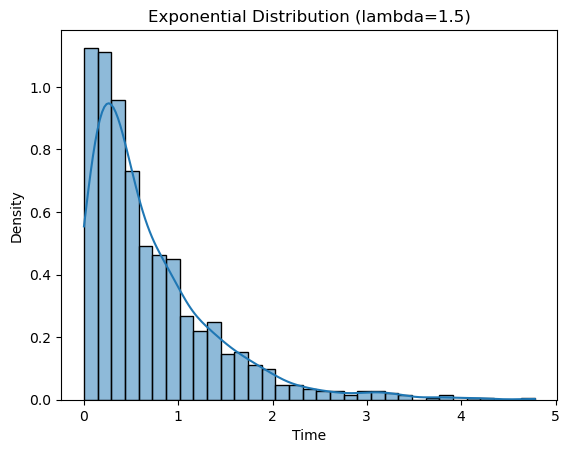

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the rate parameter lambda
lam = 1.5

# Generate exponential data
data = np.random.exponential(1/lam, 1000)

# Plot the KDE and histogram
sns.histplot(data, kde=True, stat="density")
plt.title("Exponential Distribution (lambda=1.5)")
plt.xlabel("Time")
plt.ylabel("Density")
plt.show()

**Example**

Suppose calls come into a customer support center at an average rate of 2 per minute. What is the probability that you wait more than 30 seconds for the next call?

In [ ]:
import numpy as np
from math import e
# Identify P (x>0.5)
lam = 2
x = 0.5 # 30 seconds

# Calculate the probability
p_x = e**(-lam * x)
print("Probability that you wait more than 30 seconds for the next call", p_x)

Probability that you wait more than 30 seconds for the next call 0.36787944117144233


Note that in this case I used not the CDF (P(X≤x)) which would be ```1-e**(-lam * x)``` but the Survival function (probability the event happens after time x) - P(X>x)

**Use Case 1** — Time until a user adopts a second feature

Your company observes that single-feature users adopt a second feature at an average rate of 8% per year.

**Task:**
- What is the probability that a user adopts another feature within 3 years?
- What is the probability that the user still has not adopted another feature after 5 years?
- What is the expected time until adoption?

In [ ]:
# Probability that a user adopts another feature within 3 years
# In this case we use the CDF because we calculate (P(X≤x))
lam = 0.08
x = 3
p_x = 1 - e**(-lam*x)
print("Probability that a user adopts another feature within 3 years", p_x)

# Probability that the user still has not adopted another feature after 5 years
# In this case we use the Survival function because we calculate (P(X>x))
x = 5
p_x = e**(-lam*x)
print("Probability that the user still has not adopted another feature after 5 years", p_x)

# Expected time until adoption
# In this case we use the expected value of the exponential distribution
# E(X) = 1/lambda
E_x = 1/lam
print("Expected time until adoption", E_x)


Probability that a user adopts another feature within 3 years 0.21337213893344653
Probability that the user still has not adopted another feature after 5 years 0.6703200460356393
Expected time until adoption 12.5


**Use Case 2** — Time until customer upgrade

Customers upgrade from basic plan → premium plan at an average rate of 12% per year.

**Task:**

- Probability a customer upgrades within 2 years
- Probability the customer upgrades after more than 4 years

In [7]:
# Probability a customer upgrades within 2 years
lam = 0.12
p_x = 1 - e**(-lam*2)
print("Probability a customer upgrades within 2 years", p_x)

# Probability the customer upgrades after more than 4 years
x = 4
p_x = e**(-lam*x)
print("Probability the customer upgrades after more than 4 years", p_x) 

Probability a customer upgrades within 2 years 0.21337213893344653
Probability the customer upgrades after more than 4 years 0.6187833918061408


## Log normal distribution

The log-normal distribution is a right skewed continuous probability distribution, meaning it has a long tail towards the right. It is used for modelling various natural phenomena such as income distributions, the length of chess games or the time to repair a maintainable system and more. 

A variable follows a log-normal distribution if: The logarithm of the variable is normally distributed.

![image](https://miro.medium.com/v2/resize:fit:1290/format:webp/1*5yM7k43zgHzE_twI-Y9DXA.png)


**PDF (Probability Density Function):**

![image](media/log-normal.png)


**CDF (Cumulative Distribution Function):**

![image](media/log_normal_cdf.png)

In [ ]:
from math import log, exp, sqrt, pi, e
import numpy as np
from scipy.stats import norm

salaries = [10,12,12,14,14,15,18,18,29,35,60,90,100,250,1000,10000,20000]
log_salaries = np.log(salaries)
print("log salaries", log_salaries)

log_mean = np.mean(log_salaries)
print("log mean", log_mean)

log_std = np.std(log_salaries, ddof=1)
print("log std", log_std)

# probability of salary above 100 - CDF
log_x = np.log(x)
log_x_z = (log_x-log_mean)/log_std
p_x = 1 - norm.cdf(log_x_z)
print('probability of salary above 100', p_x)

# probability of salary below 100 - CDF
p_x = norm.cdf(log_x_z)
print('probability of salary below 100', p_x)

log salaries [2.30258509 2.48490665 2.48490665 2.63905733 2.63905733 2.7080502
 2.89037176 2.89037176 3.36729583 3.55534806 4.09434456 4.49980967
 4.60517019 5.52146092 6.90775528 9.21034037 9.90348755]
log mean 4.276724658827538
log std 2.3451827414262567
probability of salary 100 0.0016845122756730464
probability of salary above 100 0.44430979051536246
probability of salary below 100 0.5556902094846375


In order to calculate probbaility of P(X>x) we need to log(x), then normalize log_x using the z-score and then simply apply the CUmulative Distribution Function for normal distributions. The logic is that when log-normal distribution is transformed to log, then it actually follows the logic of normal distribution, hence, normal distribution CDF works well. 

**Problem**

Customer Purchase Size (E-commerce)
An online store observes that customer purchase amounts follow a log-normal distribution.
From transaction logs:
𝜇 = 4.5
𝜎 = 1.1

Questions:
- 1️⃣ What is the probability a purchase exceeds $200?
- 2️⃣ What percentage of purchases are below $20?
- 3️⃣ What is the expected purchase value?


In [ ]:
import numpy as np
from scipy.stats import norm
from math import e

log_mean = 4.5
log_std = 1.1

# what is the probability a purchase exceeds $200?
x = 200
log_x = np.log(200)
log_x_z = (log_x-log_mean)/log_std
p_x = 1 - norm.cdf(log_x_z)
print('probability a purchase exceeds $200', p_x)

# what percentage of purchases are below $20?
x = 20
log_x = np.log(x)
log_x_z = (log_x-log_mean)/log_std
p_x = norm.cdf(log_x_z)
print('percentage of purchases are below $20', p_x)

# what is the expected purchase value?
E_x = e**(log_mean+log_std**2/2)
print('expected purchase value', E_x)


probability a purchase exceeds $200 0.23399814938217844
percentage of purchases are below $20 0.08573179482277238
expected purchase value 164.84407053164128


## Central Limit Theorem

The Core Idea:

If you repeatedly take samples from any population (with a finite mean and variance) and compute the average of each sample, the distribution of those sample averages will approach a normal distribution as the sample size grows.

In simple terms:
- Your original data can be skewed, uniform, or messy
- But the averages of samples from that data tend to form a bell curve

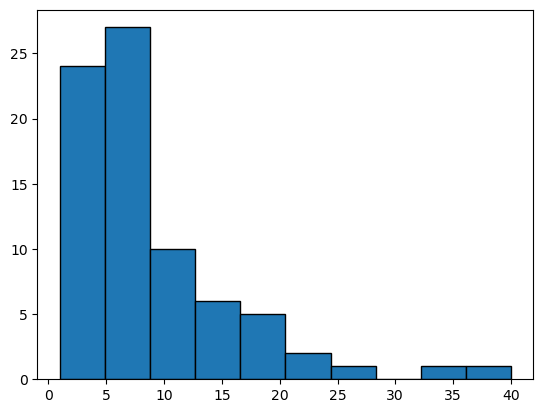

mean 8.545454545454545
standard deviation 7.436654338558178


In [ ]:
from matplotlib import pyplot as plt
import numpy as np
# sample data

x = [1,1,1,1,1,2,2,2,2,2,2,3,3,3,3,3,3,4,4,4,4,4,4,4,5,5,5,5,5,5,5,5,6,6,6,6,6,7,7,7,7,7,7,7,7,7,8,8,8,8,8,9,9,9,9,9,10,10,10,10,12,13,13,14,15,15,15,17,17,18,19,20,22,24,28,35,40]

# plot the sample data
plt.hist(x, bins=10, edgecolor='black')
plt.show()

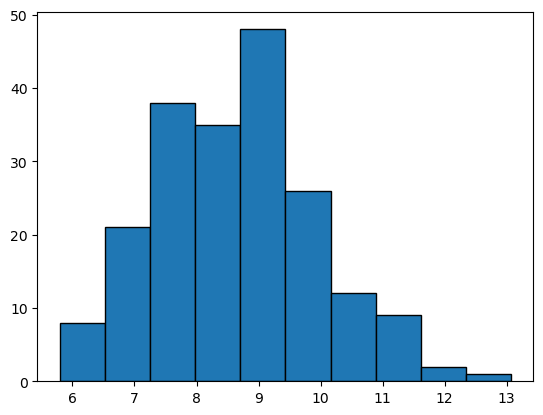

In [18]:
# randomly select samples from the sample data and calculate the mean of each sample
sample_means = []
for i in range(200):
    sample = np.random.choice(x, size=30, replace=True)
    sample_means.append(np.mean(sample))

# plot the sample means
plt.hist(sample_means, bins=10, edgecolor='black')
plt.show()


The distribution of 200 means is very close to normal.